# Entropy plots — one example of each type, with algorithm filtering

Loads one dimension's **precomputed** entropy CSVs (from `entropy_calculation.py`)
and shows one example of each plot type inline.

**Filtering:** the data files keep *all* algorithms; filtering happens only at
plot time via the `ALGOS` variable in the setup cell. Set it to `None` to show
everything, or to a list of names to narrow the view for a clearer picture.

**Prerequisite:** run `python entropy_calculation.py` first.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import entropy_plotting as ep
from entropy_calculation import ENTROPY_DATA_DIR, ALGORITHMS_OF_INTEREST

DIM = 5

# Example subsets:
#   WOA/GWO family: ["HI_WOA","OriginalWOA","WhaleFOA","GWO_WOA","OriginalGWO","IGWO","RW_GWO"]
#   DE family:      ["JADE","OriginalDE","SADE","OriginalSHADE","L_SHADE"]
#   AEO family:     ["ModifiedAEO","OriginalAEO","AugmentedAEO"]
ALGOS = ["OriginalDE","SADE","OriginalSHADE","AugmentedAEO", "GWO_WOA", "OriginalCSA", "OriginalMRFO"]
print("Available algorithms:")
print(sorted(ALGORITHMS_OF_INTEREST))

Available algorithms:
['AugmentedAEO', 'GWO_WOA', 'HI_WOA', 'IGWO', 'ImprovedBSO', 'JADE', 'L_SHADE', 'LevyTWO', 'ModifiedAEO', 'OriginalAEO', 'OriginalALO', 'OriginalCSA', 'OriginalDE', 'OriginalFPA', 'OriginalGWO', 'OriginalHC', 'OriginalHHO', 'OriginalMFO', 'OriginalMPA', 'OriginalMRFO', 'OriginalNMRA', 'OriginalSHADE', 'OriginalSSA', 'OriginalSSpiderA', 'OriginalWOA', 'RW_GWO', 'SADE', 'WhaleFOA']


In [3]:
agg_path = f"{ENTROPY_DATA_DIR}/entropy_dim_{DIM}.csv"
gran_path = f"{ENTROPY_DATA_DIR}/entropy_granular_dim_{DIM}.csv"

all_entropy = pd.read_csv(agg_path)
granular = pd.read_csv(gran_path)

print("aggregated:", all_entropy.shape, "->", list(all_entropy.columns))
print("granular:  ", granular.shape, "->", list(granular.columns))
all_entropy.head()

aggregated: (13440, 4) -> ['algorithm', 'iteration', 'function_class', 'mean_entropy']
granular:   (336000, 7) -> ['algorithm', 'problem_id', 'instance_id', 'dimension', 'run', 'iteration', 'entropy']


,algorithm,iteration,function_class,mean_entropy
0,AugmentedAEO,1.0,1,0.635289
1,AugmentedAEO,2.0,1,0.497491
2,AugmentedAEO,3.0,1,0.421238
3,AugmentedAEO,4.0,1,0.323927
4,AugmentedAEO,5.0,1,0.231724


## 1. `plot_entropy_by_function_group`
All (or filtered) algorithms' normalized entropy over iterations, one panel per BBOB function group.
The `algorithms=ALGOS` argument does the filtering.

In [4]:
import os
os.makedirs(f"figures_entropy/dim_{DIM}", exist_ok=True)

# saves the PDF (respecting the ALGOS filter)
ep.plot_entropy_by_function_group(all_entropy.copy(), f"figures_entropy/dim_{DIM}",
                                  ep.FUNCTION_GROUPS, algorithms=ALGOS)
print(f"saved -> figures_entropy/dim_{DIM}/entropy_across_function_groups.pdf")

saved -> figures_entropy/dim_5/entropy_across_function_groups.pdf


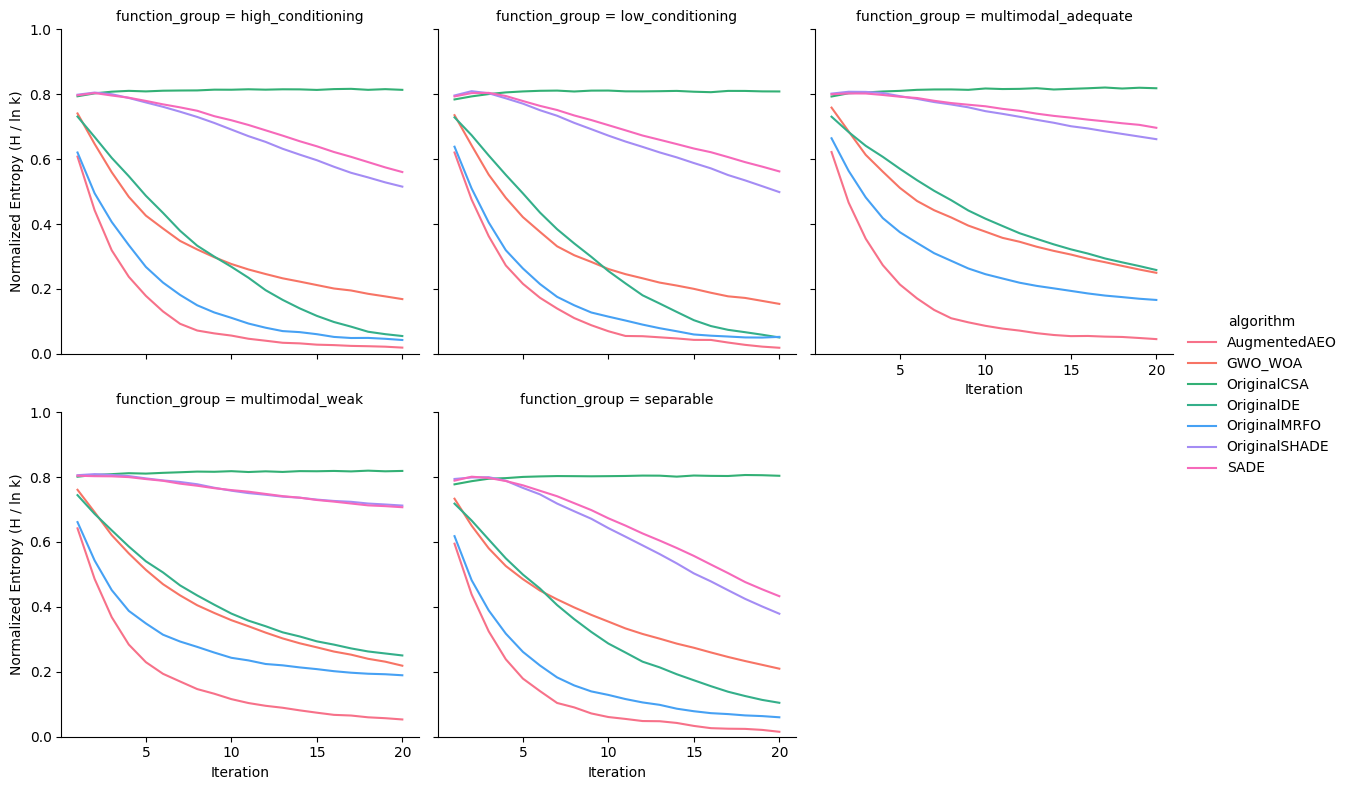

In [7]:
# inline preview (same logic, no save/close so it renders here)
data = ep._filter_algorithms(all_entropy, ALGOS)
function_to_group = {f: g for g, fs in ep.FUNCTION_GROUPS.items() for f in fs}
tmp = data.copy()
tmp['function_group'] = tmp['function_class'].map(function_to_group)
group_entropy = tmp.groupby(['algorithm','iteration','function_group'])['mean_entropy'].mean().reset_index()

algo_order = sorted(group_entropy['algorithm'].unique())
palette = {a: ep.ALGO_PALETTE[a] for a in algo_order}

g = sns.FacetGrid(group_entropy, col='function_group', col_wrap=3, height=4,
                  hue='algorithm', hue_order=algo_order, palette=palette)
g.map_dataframe(sns.lineplot, x='iteration', y='mean_entropy')
g.set(ylim=(0,1))
g.set_axis_labels('Iteration', 'Normalized Entropy (H / ln k)')
g.add_legend()
plt.savefig(f"figures_entropy/entropy_function_groups_dim{DIM}.pdf")
plt.show()

## 2. `plot_entropy_clustermap`
Algorithm × iteration heatmap, rows clustered by similarity. All row labels are forced
on (no thinning), and filtering to fewer algorithms makes the map much easier to read.
With <2 algorithms it falls back to a plain heatmap (a dendrogram needs >=2 rows).

In [8]:
# saves the PDF (respecting the ALGOS filter, all labels shown)
ep.plot_entropy_clustermap(all_entropy.copy(), f"figures_entropy/dim_{DIM}", algorithms=ALGOS)
print(f"saved -> figures_entropy/dim_{DIM}/clustermap.pdf")

saved -> figures_entropy/dim_5/clustermap.pdf


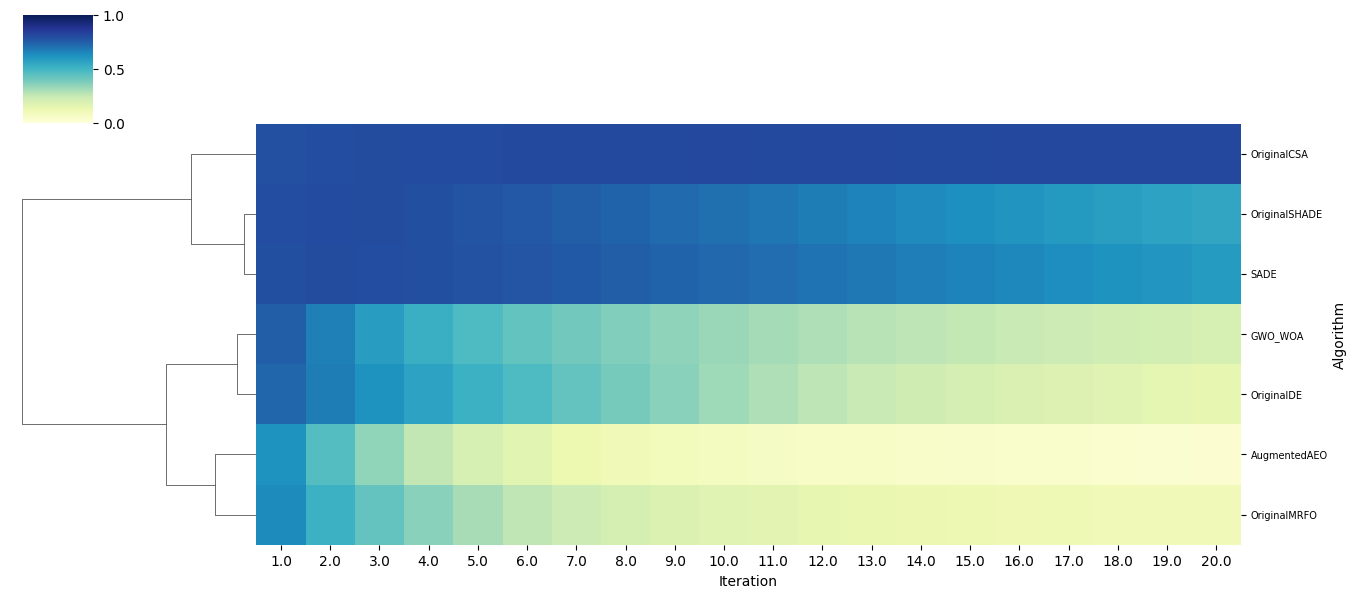

In [9]:
# inline preview with all row labels forced on
data = ep._filter_algorithms(all_entropy, ALGOS)
matrix = data.groupby(['algorithm','iteration'])['mean_entropy'].mean().unstack(level='iteration')
n = matrix.shape[0]

if n < 2:
    plt.figure(figsize=(14, max(3, n*0.5+1)))
    ax = sns.heatmap(matrix, cmap='YlGnBu', vmin=0, vmax=1,
                     cbar_kws={'label':'Normalized Entropy (H / ln k)'})
    ax.set_xlabel('Iteration'); ax.set_ylabel('Algorithm')
    plt.yticks(rotation=0, fontsize=7)
else:
    cg = sns.clustermap(matrix, cmap='YlGnBu', figsize=(14, max(6, n*0.35)),
                        annot=False, standard_scale=None, col_cluster=False, vmin=0, vmax=1)
    reordered = cg.dendrogram_row.reordered_ind
    cg.ax_heatmap.set_yticks([i+0.5 for i in range(n)])
    cg.ax_heatmap.set_yticklabels([matrix.index[i] for i in reordered], fontsize=7, rotation=0)
    cg.ax_heatmap.set_xlabel('Iteration'); cg.ax_heatmap.set_ylabel('Algorithm')
plt.show()

## 3. `plot_entropy` (single function/instance line plot)
Per-function view, reconstructed from the granular data for one (function, instance),
averaged across runs. Also respects the `ALGOS` filter.

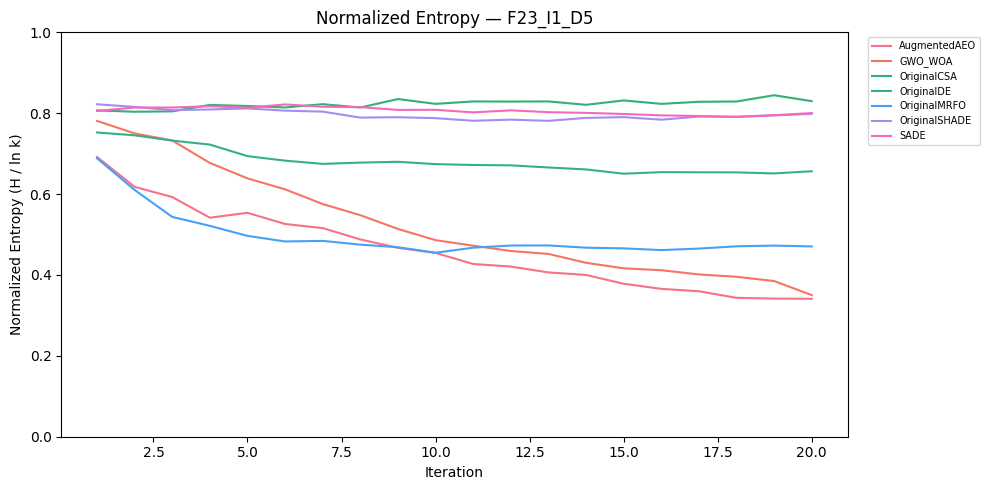

In [7]:
F, I = 23, 1
sub = granular[(granular['problem_id']==F) & (granular['instance_id']==I)].copy()
sub = ep._filter_algorithms(sub, ALGOS)
sub_mean = sub.groupby(['algorithm','iteration'])['entropy'].mean().reset_index()

plt.figure(figsize=(10,5))
algo_order = sorted(sub_mean['algorithm'].unique())
palette = {a: ep.ALGO_PALETTE[a] for a in algo_order}
sns.lineplot(data=sub_mean, x='iteration', y='entropy', hue='algorithm',
             hue_order=algo_order, palette=palette, errorbar=None)
plt.title(f'Normalized Entropy — F{F}_I{I}_D{DIM}')
plt.xlabel('Iteration'); plt.ylabel('Normalized Entropy (H / ln k)')
plt.ylim(0,1)
plt.legend(bbox_to_anchor=(1.02,1), loc='upper left', fontsize=7)
plt.tight_layout()
plt.show()

## 4. `plot_entropy_overlay` (cross-dimension)
Compares functions across dimensions, faceted `dim` × `algorithm`. Since that grid is
one column per algorithm, the `ALGOS` filter matters even more here for readability —
a couple of algorithms is usually all you want.

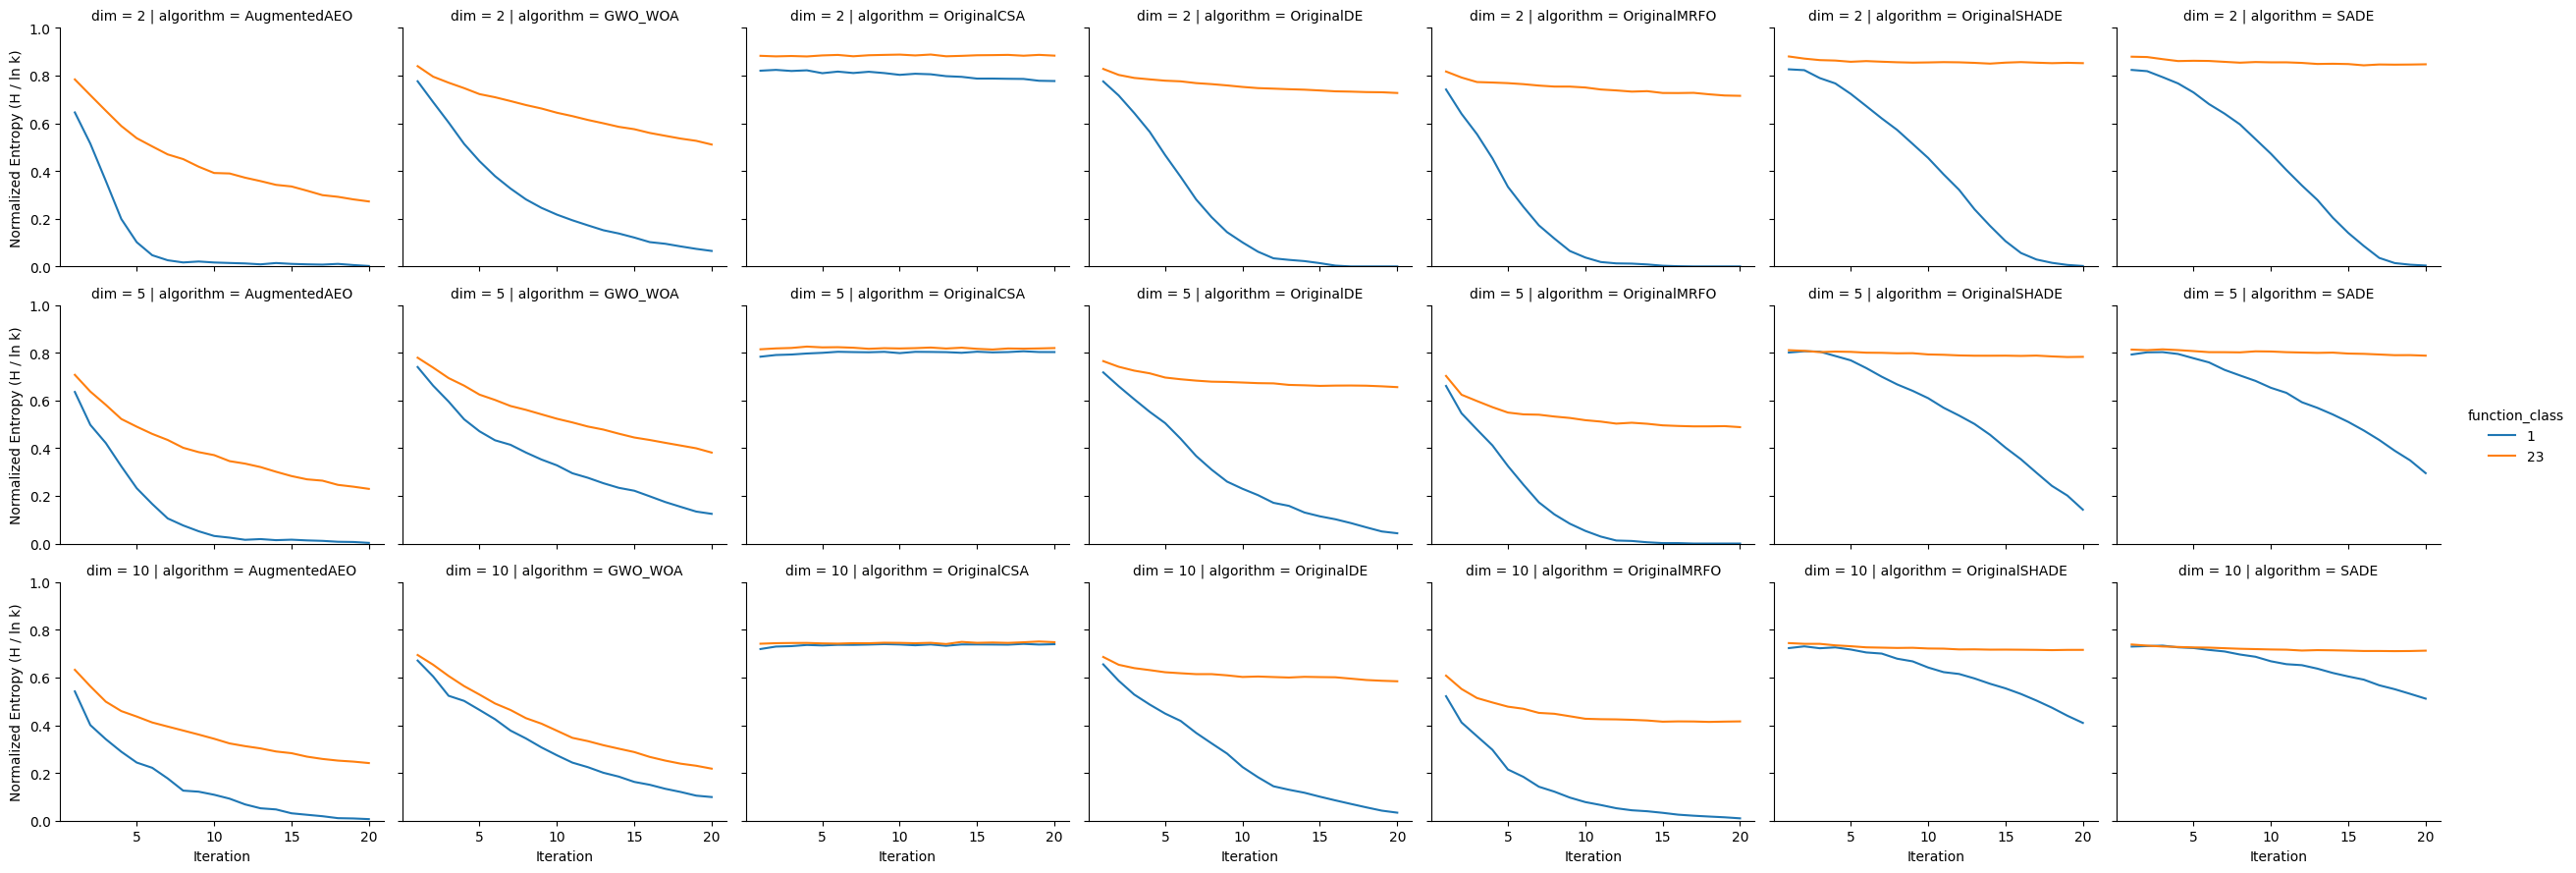

In [10]:
all_by_dim = {}
for d in [2, 5, 10]:
    p = f"{ENTROPY_DATA_DIR}/entropy_dim_{d}.csv"
    try:
        all_by_dim[d] = pd.read_csv(p)
    except FileNotFoundError:
        print("missing", p, "- run entropy_calculation.py for that dim")

# For overlay, if ALGOS is None it'd make a 28-col grid - too wide. Fall back
# to a small readable subset for this specific plot when nothing is filtered.
overlay_algos = ALGOS if ALGOS is not None else ['OriginalDE', 'OriginalWOA']
preview_funcs = [1, 23]  # one separable, one multimodal

ep.plot_entropy_overlay(all_by_dim, preview_funcs, list(all_by_dim.keys()),
                        output_dir="figures_entropy", save=False, algorithms=overlay_algos)

# inline preview
rows = []
for d, df in all_by_dim.items():
    s = ep._filter_algorithms(df, overlay_algos)
    s = s[s['function_class'].isin(preview_funcs)].copy()
    s['dim'] = d
    rows.append(s)
combined = pd.concat(rows, ignore_index=True)
combined['function_class'] = combined['function_class'].astype(str)

g = sns.FacetGrid(combined, row='dim', col='algorithm', height=3, aspect=1.2,
                  hue='function_class', palette='tab10')
g.map_dataframe(sns.lineplot, x='iteration', y='mean_entropy')
g.set(ylim=(0,1))
g.set_axis_labels('Iteration', 'Normalized Entropy (H / ln k)')
g.add_legend()
plt.savefig('figures_entropy/uni_vs_multimodal.pdf', bbox_inches="tight")
plt.show()

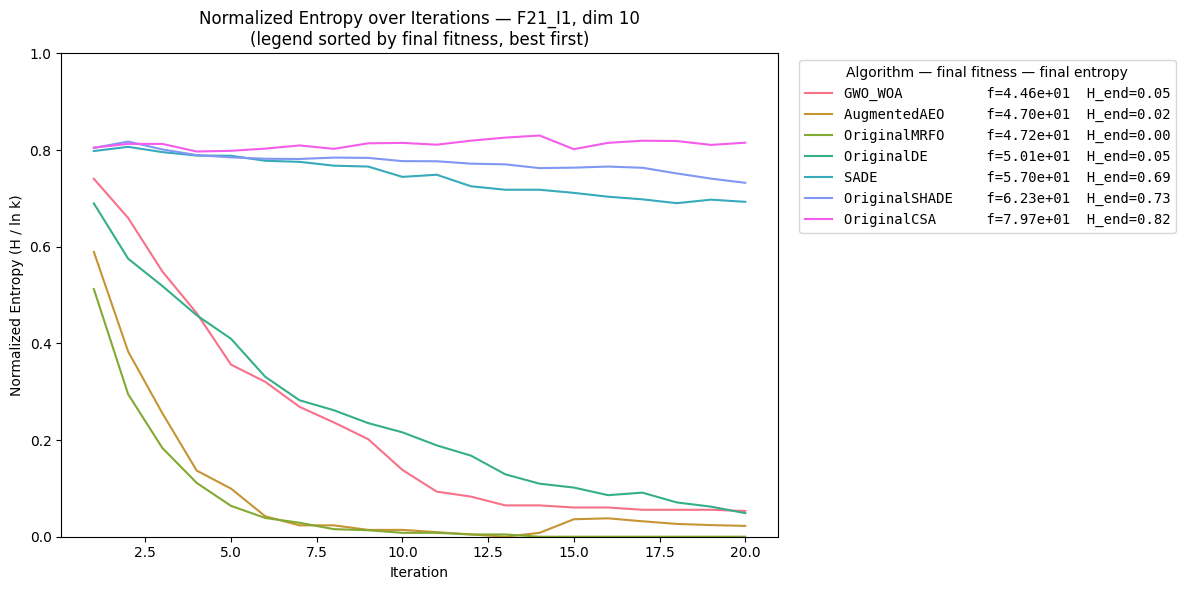

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ---- knobs ----
DIM = 10
F, I = 21, 1
ALGOS_FILTERED = []

# --- entropy curves (mean over runs) ---
gran = pd.read_csv(f'data/entropy/entropy_granular_dim_{DIM}.csv')
ent = gran[(gran['problem_id'] == F) & (gran['instance_id'] == I) &
           (gran['algorithm'].isin(ALGOS))]
ent_mean = ent.groupby(['algorithm', 'iteration'])['entropy'].mean().reset_index()

# final entropy = entropy at the LAST iteration (mean over runs)
last_iter = ent_mean['iteration'].max()
final_ent = (ent_mean[ent_mean['iteration'] == last_iter]
             .set_index('algorithm')['entropy'])

# --- final fitness (mean over runs) ---
res = pd.read_csv(f'outputs/dim_{DIM}/results.csv')
fit = res[(res['problem_id'] == F) & (res['instance_id'] == I) &
          (res['algorithm'].isin(ALGOS))]
final_fit = fit.groupby('algorithm')['fitness'].mean()

# order best (lowest) fitness -> worst, so the legend doubles as a ranking
order = final_fit.sort_values().index.tolist()

# --- plot ---
plt.figure(figsize=(12, 6))
palette = dict(zip(order, sns.color_palette('husl', len(order))))

for alg in order:
    sub = ent_mean[ent_mean['algorithm'] == alg].sort_values('iteration')
    label = f"{alg:16s} f={final_fit[alg]:.2e}  H_end={final_ent[alg]:.2f}"
    plt.plot(sub['iteration'], sub['entropy'], color=palette[alg], label=label, linewidth=1.5)

plt.title(f'Normalized Entropy over Iterations — F{F}_I{I}, dim {DIM}\n'
          f'(legend sorted by final fitness, best first)')
plt.xlabel('Iteration')
plt.ylabel('Normalized Entropy (H / ln k)')
plt.ylim(0, 1)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8,
           title='Algorithm — final fitness — final entropy',
           prop={'family': 'monospace'})   # monospace keeps the columns aligned
plt.tight_layout()
plt.savefig(f'figures_entropy/entropy_fitness_F{F}_I{I}_dim{DIM}.pdf', bbox_inches='tight')
plt.show()